In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [2]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 5/2



if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [4]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_theta(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, es: np.ndarray, erange, r, theta, b
) -> list[pi.SystemPair]:

    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif))
    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif))

    

    pair_systems = []
    for i, e in enumerate(es):
                
        # print(f'pair energy = {pair_energy}{energy_unit}')
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm'), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm')


        pi.diagonalize([system1, system2])

        pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
        min_energy, max_energy = pair_energy - erange, pair_energy + erange

        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=theta)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )
    
    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in pair_systems]

    return pair_systems, states_num, energies


In [5]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   change1  change2     defect       c3k  asymmetry 10um  energy 10um  \
0        1       -2  19.646767 -3.890497     -143.490614    -0.379007   
1        1       -2  26.702835 -1.004522     -143.752471    -0.379699   
2        1       -2 

In [6]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']


bfield = 0  # Gauss



Magnetic file doesn't exist


In [10]:

n1_0, l1_0, j1_0 = 59, 2, 3/2
n2_0, l2_0, j2_0 = 59, 2, 3/2
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = 61, 1, 1/2
n2_1, l2_1, j2_1 =  57, 3, 5/2
defect=8.71
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

In [11]:
basis1 = pi.BasisAtom(ket1.species, n=(ket1.n, ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))
print(basis1.kets)

[KetAtom(Rb:59,D_3/2,-3/2), KetAtom(Rb:59,D_3/2,-1/2), KetAtom(Rb:59,D_3/2,1/2), KetAtom(Rb:59,D_3/2,3/2)]


In [12]:
thetas = [0]
b=6
es = np.linspace(0, .2, 500)
r=10
erange = abs(defect * 100)


In [44]:
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)
system_pairs_dict_inter = {}
system_pairs_dict_Rb = {}
system_pairs_dict_Cs = {}
energies_inter_dict = {}
energies_intra_Rb_dict = {}
energies_intra_Cs_dict = {}
for theta in thetas:
    while True:
        try:
            pairs = get_system_pair_list_theta(ket1, ket2, es, erange, r, theta, b)
            system_pairs = pairs[0]
            states_num = pairs[1]
            energies = pairs[2]
            
            system_pairs_dict_inter.update({f'{theta}{r}': system_pairs})
            energies_inter_dict.update({f'{theta}{r}' : energies})

            break
        except RuntimeError: # Replace Exception with something more specific.
            continue
    

print(system_pairs)


[SystemPair(BasisPair(|Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:57,F_7/2,-7/2; ~Rb:61,P_1/2,-1/2⟩ ... |~Rb:61,P_3/2,3/2; ~Rb:57,F_7/2,7/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb

In [45]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')
if not os.path.exists(datapath + 'intra Rb'):
    os.makedirs(datapath + 'intra Rb')
if not os.path.exists(datapath + 'intra Cs'):
    os.makedirs(datapath + 'intra Cs')


energies_inter_dict.update({'es' : es})

    

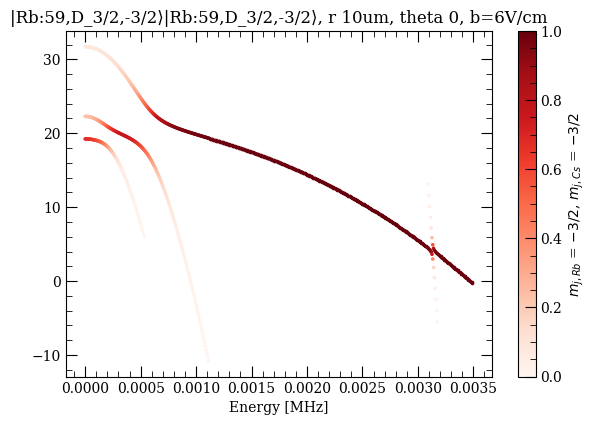

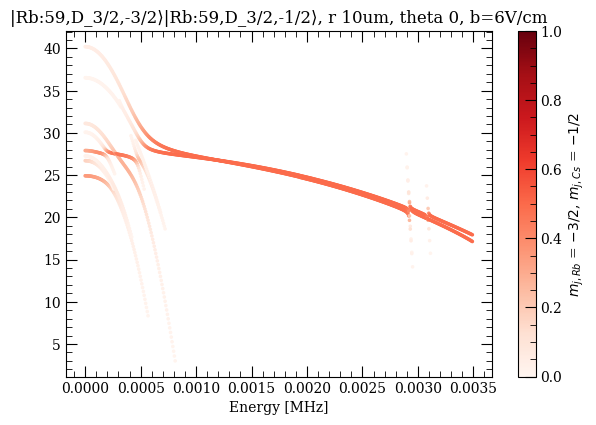

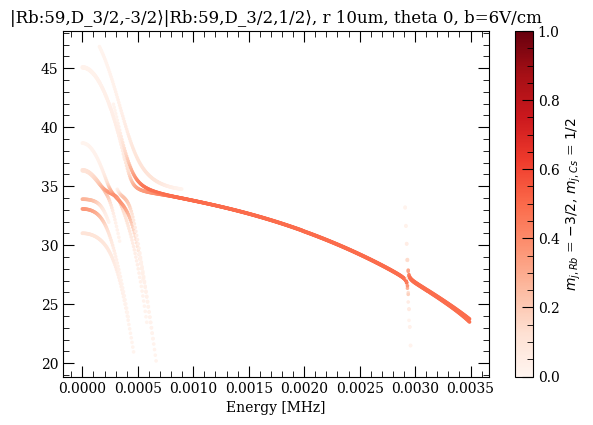

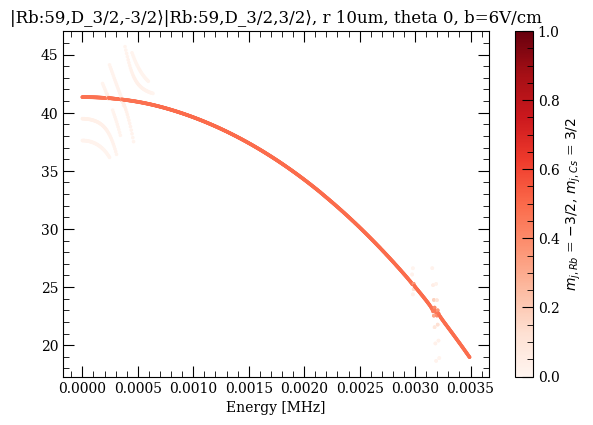

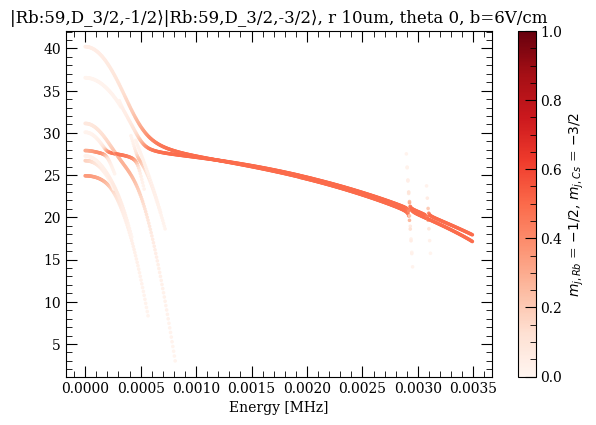

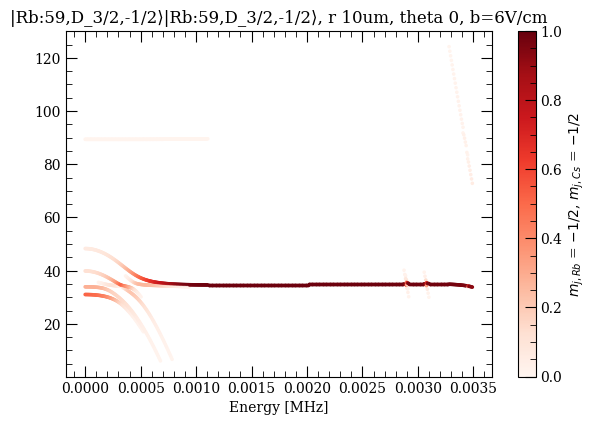

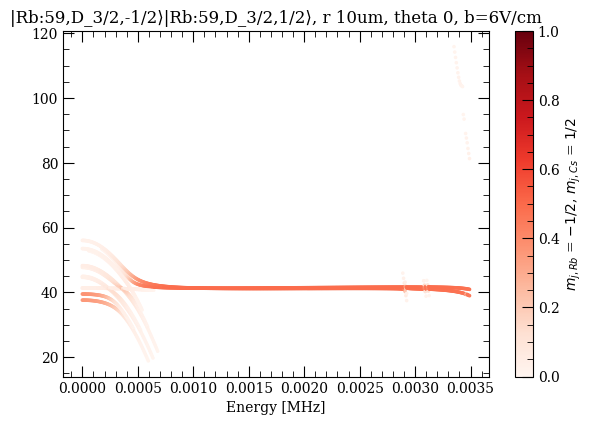

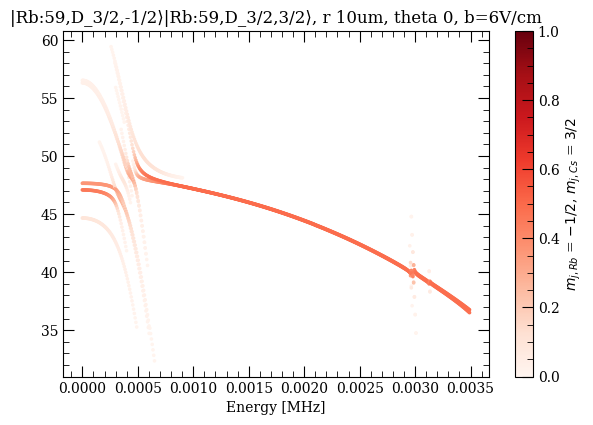

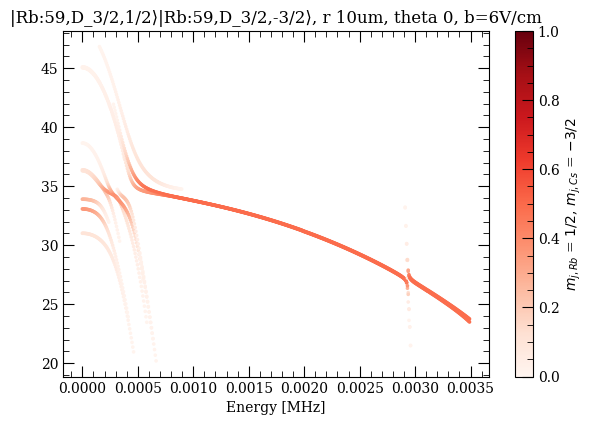

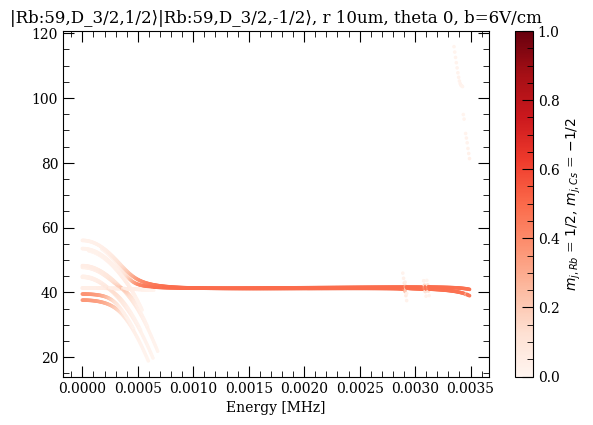

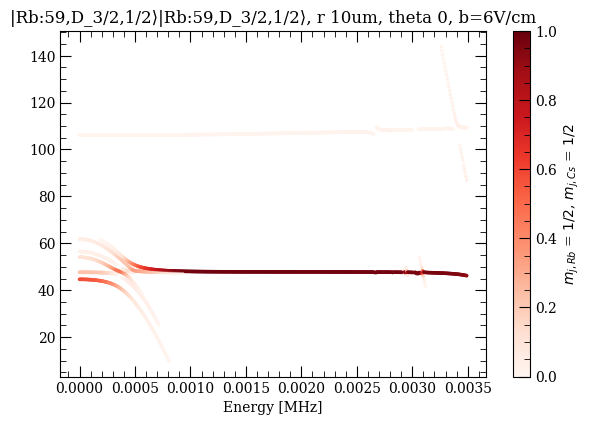

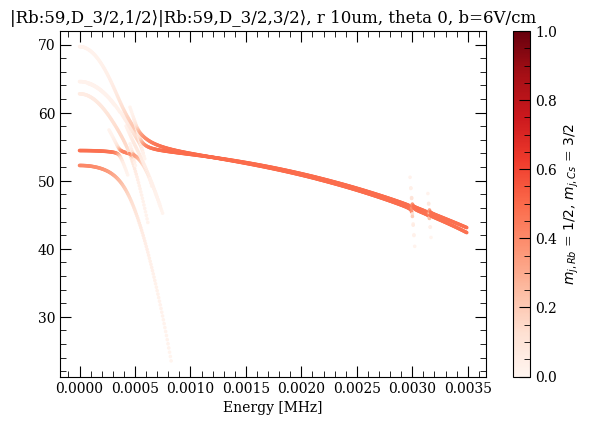

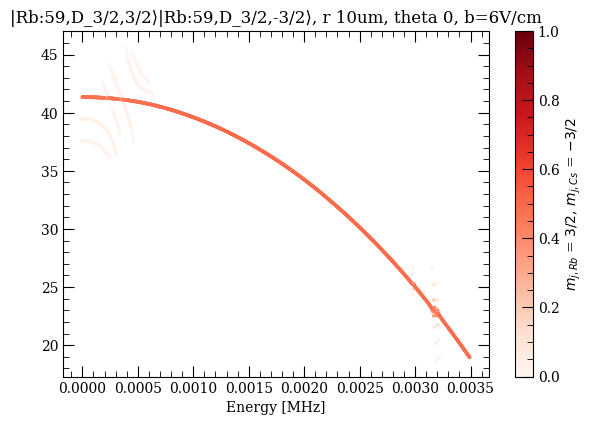

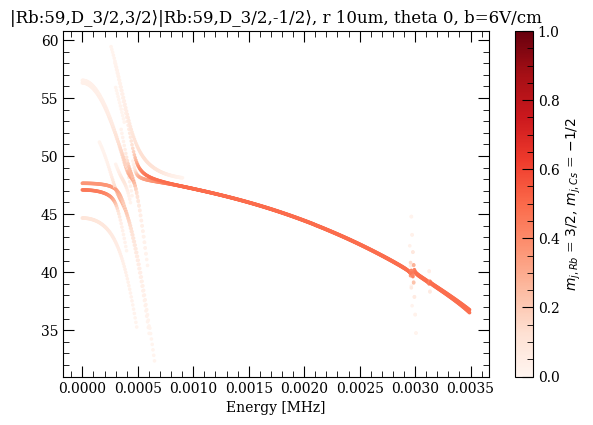

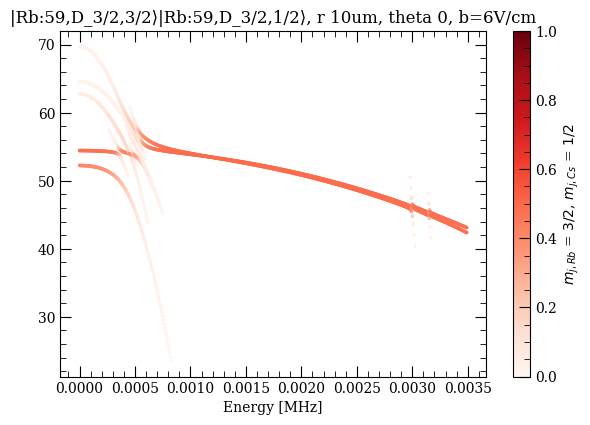

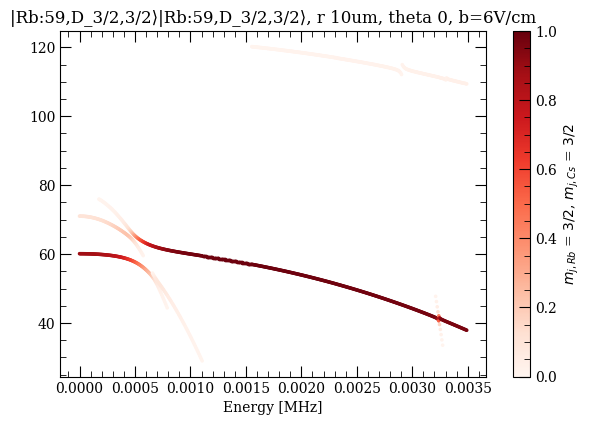

In [46]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']


for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            import os

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{theta}{r}']


            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


            energies_inter = energies_inter_dict[f'{theta}{r}']


            # print(energies_inter)
            
                    
            # 2. Build the RGBA array: (N, 4)

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)}, r {r}um, theta {theta}, b={np.round(b,3)}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            # plt.ylabel(f"Energy [{energy_unit}]")
            plt.xlabel(fr"Energy [{energy_unit}]")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            e, energy, overlap = [], [], []
            min_overlap = 0.01
            for x, ens, os in zip(es, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    e.extend([x] * len(ens[inds]))
                    energy.extend(ens[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(ens[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        np.radians([x] * len(ens[inds])),
                        ens[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'e' : np.array(e), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")

            
            plt.show()
            overlapped_intra_Cs = {'e' : np.array(e), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, r {r}um, b {b}G.csv')
            # plt.hlines((defect), xmin=electric_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'mjs{mj1},{mj2}, b {np.round(b,3)}G r {r}um theta{theta}.png')
            plt.close()


In [47]:
print(overlapped_intra_Cs)

{'e': array([0.       , 0.       , 0.0004008, ..., 0.1995992, 0.2      ,
       0.2      ], shape=(1025,)), 'energy': array([ 71.01299596,  60.108006  ,  71.01148129, ...,  37.99325657,
       109.39827633,  37.89516211], shape=(1025,)), 'overlap': array([0.10308581, 0.88289156, 0.10311011, ..., 0.96227252, 0.03112933,
       0.96212088], shape=(1025,))}


[0]
754 500


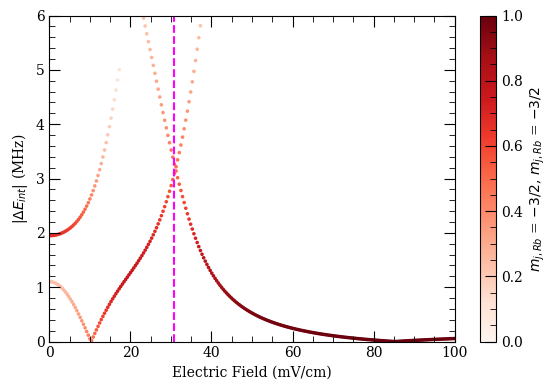

1518 977


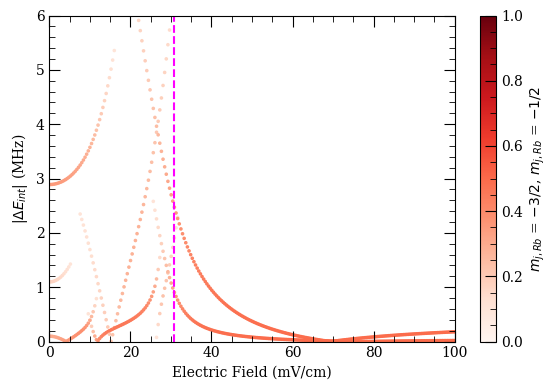

1585 622


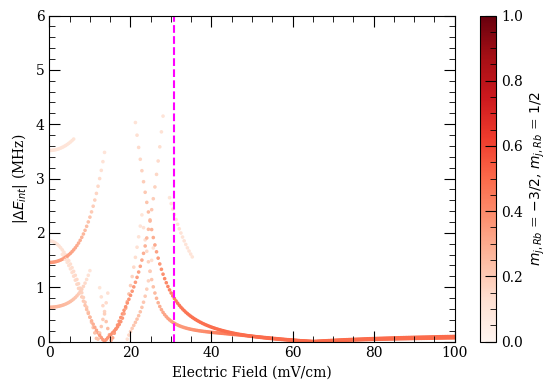

1226 616


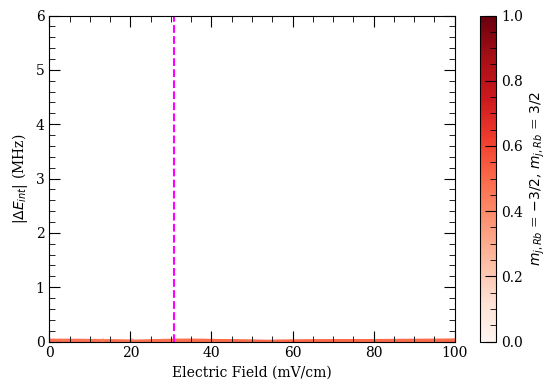

1518 977


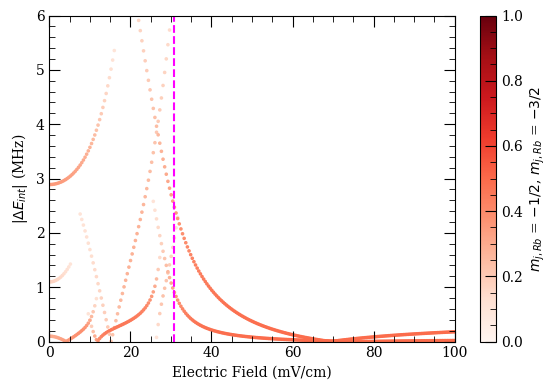

1135 551


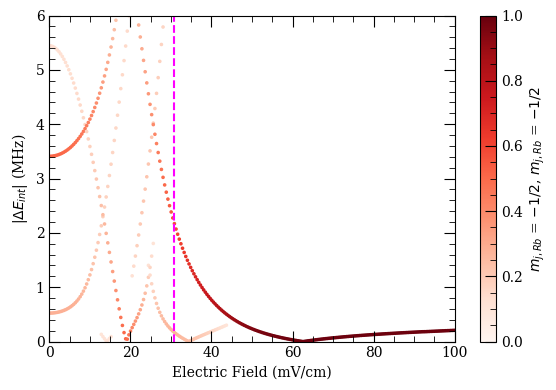

1850 800


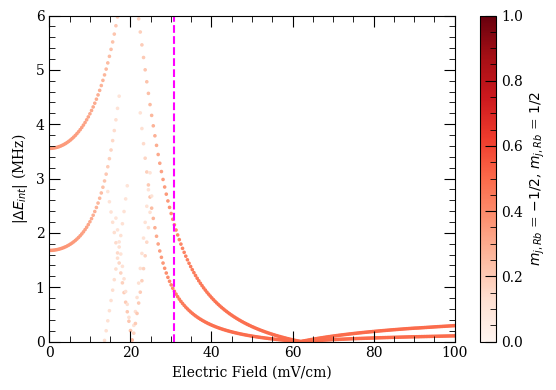

1513 633


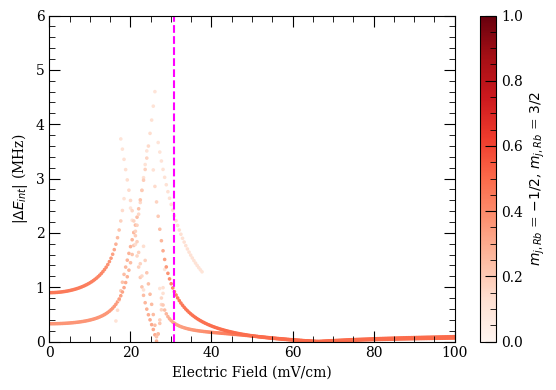

1585 622


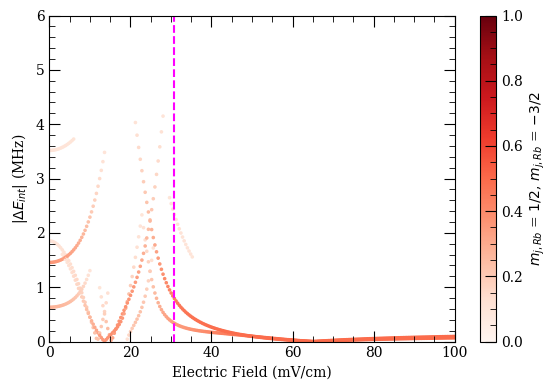

1850 800


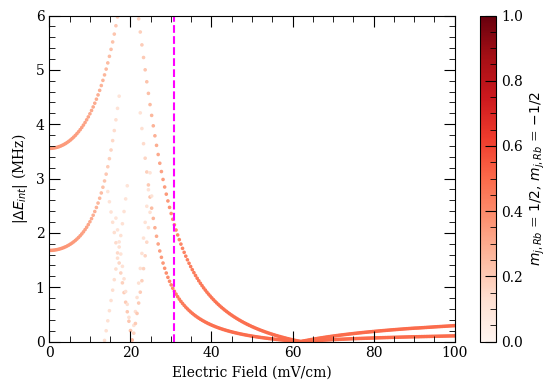

1493 889


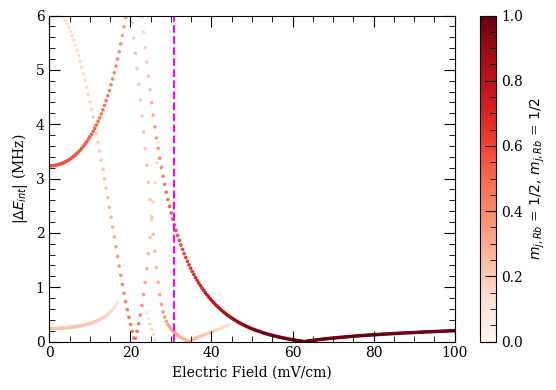

1486 1013


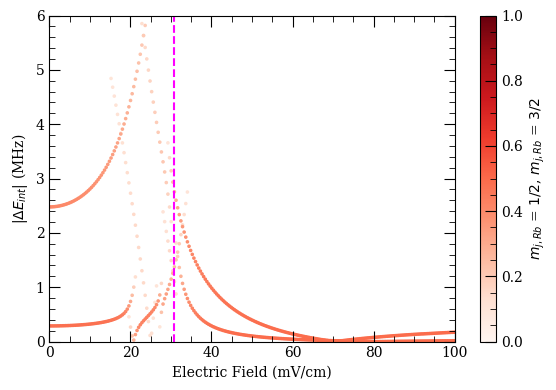

1226 616


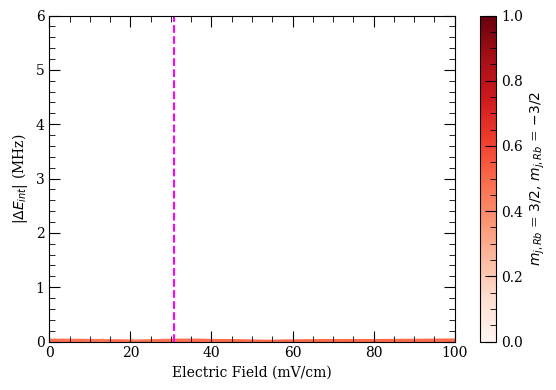

1513 633


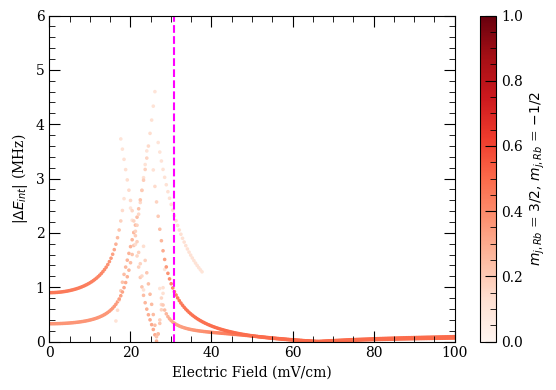

1486 1013


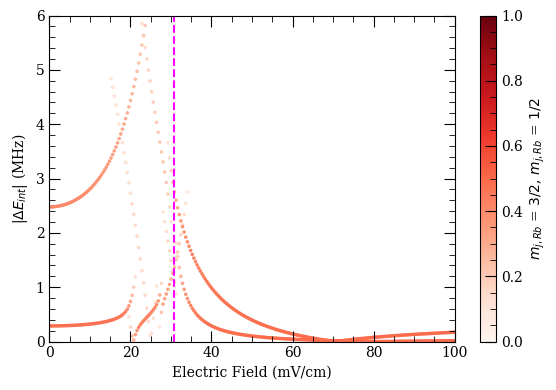

1025 778


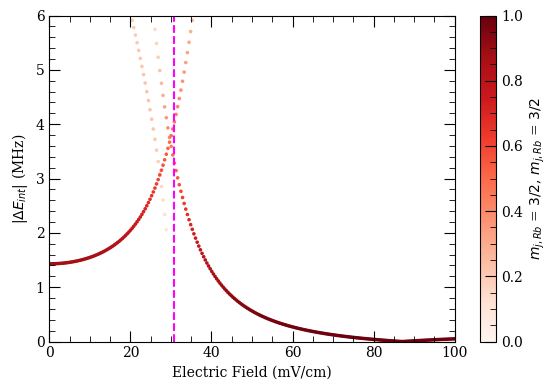

In [89]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'

import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy_electric\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]
print(thetas)
r = 10
b=6
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, r {r}um, b {b}G.csv')
            overlapped_inter_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, r {5000}um, b {b}G.csv')
            
            print(len(overlapped_inter), len(overlapped_inter_big))

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
            ax.set_ylabel(fr"|$\Delta E_{{int}}$| ({energy_unit})")
            ax.set_xlabel(f"Electric Field (mV/cm)")
            plt.tight_layout()
            # plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, theta = {np.round(theta,2)}rad, b={b}G')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            plt.ylim(0,6)
            plt.xlim(0,100)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            # ax.set_rticks([])
            # ax.set_thetagrids([])
            # ax.set_rlim([0,.5])
            min_overlap = 0.1
            energies = {'energy' : [], 'e' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            e = overlapped_inter['e'][0]
            # 1. Map b to energy from the 'big' dataset for O(1) lookup
            # This handles the "search" part instantly
            big_lookup = dict(zip(overlapped_inter_big['e'], overlapped_inter_big['energy']))
            overlap_lookup = dict(zip(overlapped_inter['e'], overlapped_inter['overlap']))

            # 2. Iterate through every single item in the original small dataset
            for j, e in enumerate(overlapped_inter['e']):
                current_energy = overlapped_inter['energy'][j]
                current_overlap = overlapped_inter['overlap'][j]
                # 3. Check if this b exists in our big lookup table
                if current_overlap >= min_overlap:
                    if e in big_lookup:
                        
                        # Subtract if match found
                        diff = current_energy - big_lookup[e]
                        energies['energy'].append(diff)
                    
                    
                # Always append these to keep lengths aligned
                        energies['e'].append(e)
                        energies['overlap'].append(overlapped_inter['overlap'][j])
            plt.axvline(x=tune*1e3, color='magenta', linestyle='dashed', label=f'Main resonance at {np.round(tune*1e3,2)} mV/cm')


            scat = plt.scatter(
                1e3 * np.array(energies['e']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )
            plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Rb}}$ = ${int(mj2*2)}/2$")
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b {np.round(b,3)}G.csv')
            fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G theta {theta}deg mjs{mj1},{mj2} min_o = {min_overlap}.png')
            plt.close()

1025 778
3.015585660934452
72
30.8617234468937


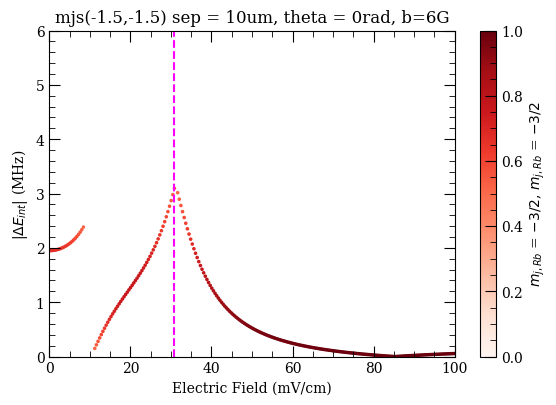

In [83]:
mj1, mj2 = -3/2, -3/2
energies = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b {np.round(b,3)}G.csv')

print(len(overlapped_inter), len(overlapped_inter_big))

fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_ylabel(fr"|$\Delta E_{{int}}$| ({energy_unit})")
ax.set_xlabel(f"Electric Field (mV/cm)")
plt.tight_layout()
plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, theta = {np.round(theta,2)}rad, b={b}G')
energy_lim = abs(defect + defect*2)
offset=defect/2
min_energy = -energy_lim+offset
max_energy = energy_lim+offset
# plt.ylim(min_energy, max_energy)
plt.ylim(0,6)
plt.xlim(0,100)

# for x, es in zip(rs, energies_inter):
#     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
# ax.set_rticks([])
# ax.set_thetagrids([])
# ax.set_rlim([0,.5])
print(max(energies['energy']))

print(list(energies['energy']).index(max(energies['energy'])))

tune = energies['e'][list(energies['energy']).index(max(energies['energy'], key=abs))]
print(tune*1000)
plt.axvline(x=tune*1e3, color='magenta', linestyle='dashed', label=f'Main resonance at {np.round(tune*1e3,2)} mV/cm')
scat = plt.scatter(
    1e3 * np.array(energies['e']),
    abs(np.array(energies['energy'])),
    c=energies['overlap'],
    s=10,
    vmin=0,
    vmax=1,
    marker='.',
    cmap = 'Reds'
)
plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Rb}}$ = ${int(mj2*2)}/2$")
plt.show()
# plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b {np.round(b,3)}G.csv')
fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G theta {theta}deg mjs{mj1},{mj2} min_o = {min_overlap}.png')
plt.close()